In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
#from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


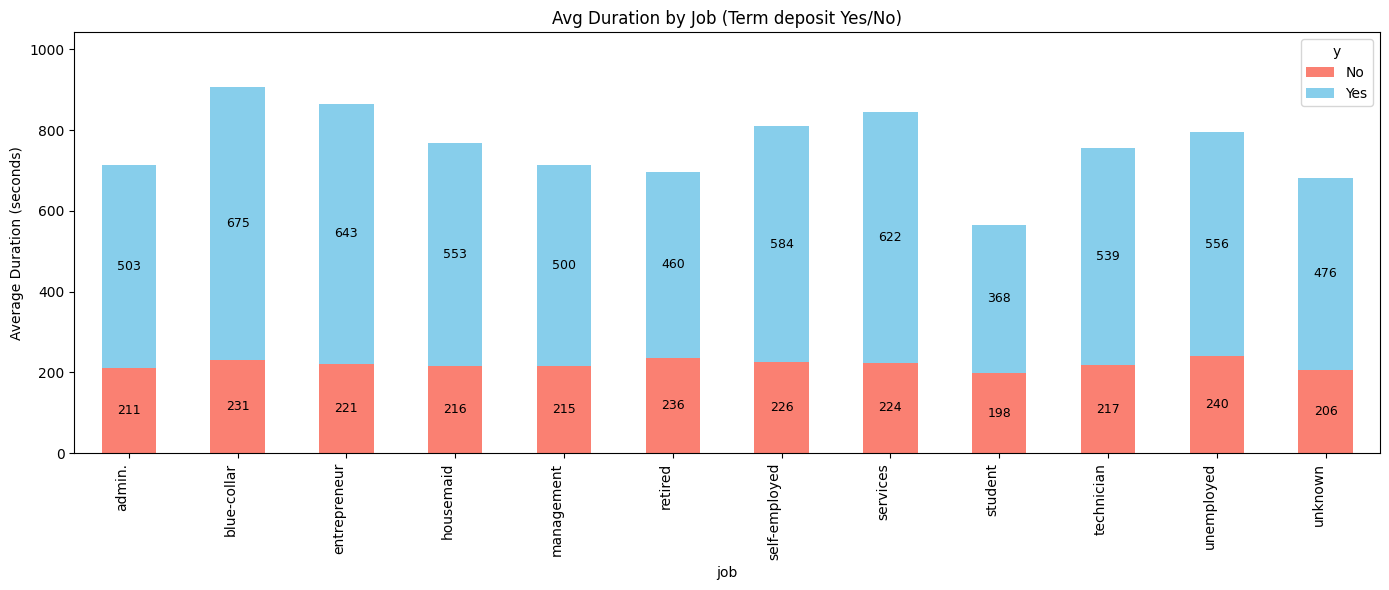

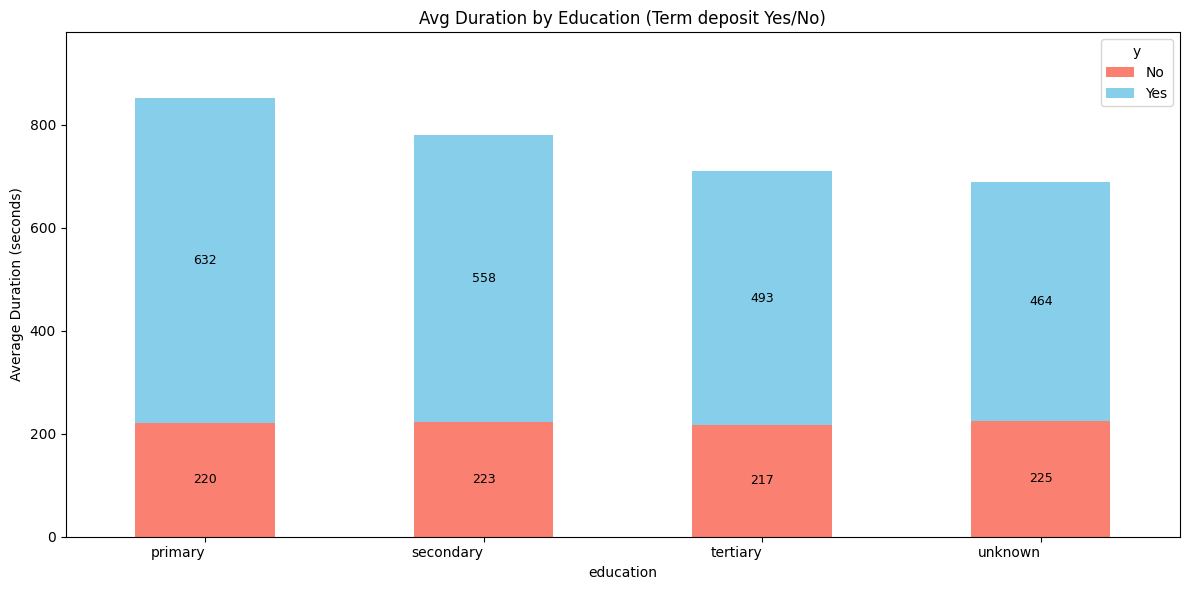

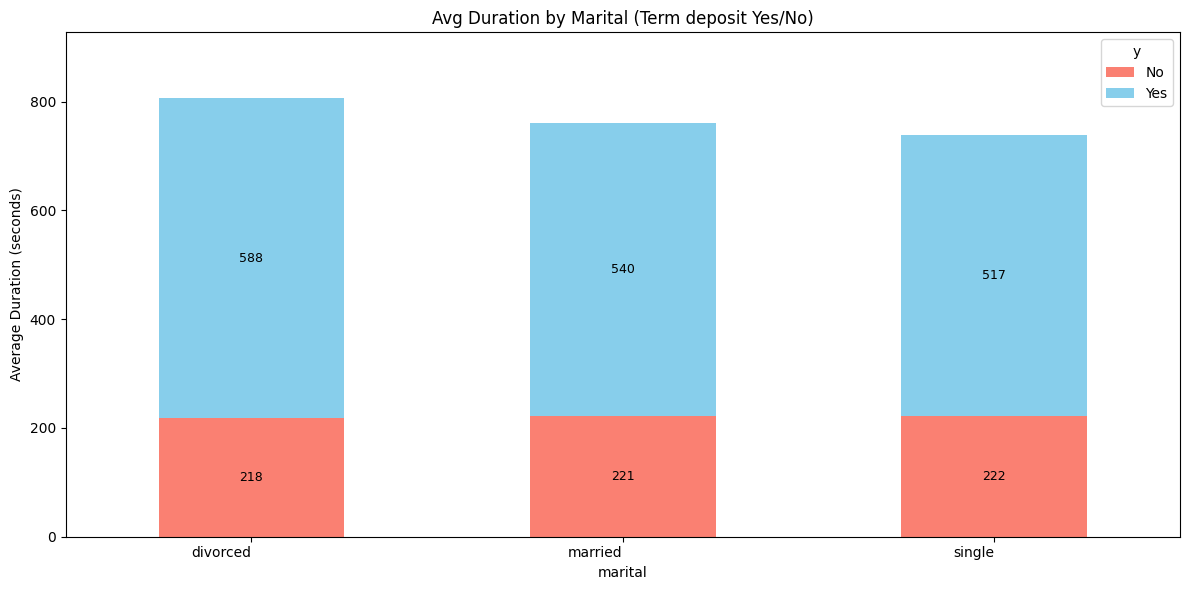

/tmp/ipykernel_488448/2040179636.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([by_col, 'y'])['duration']


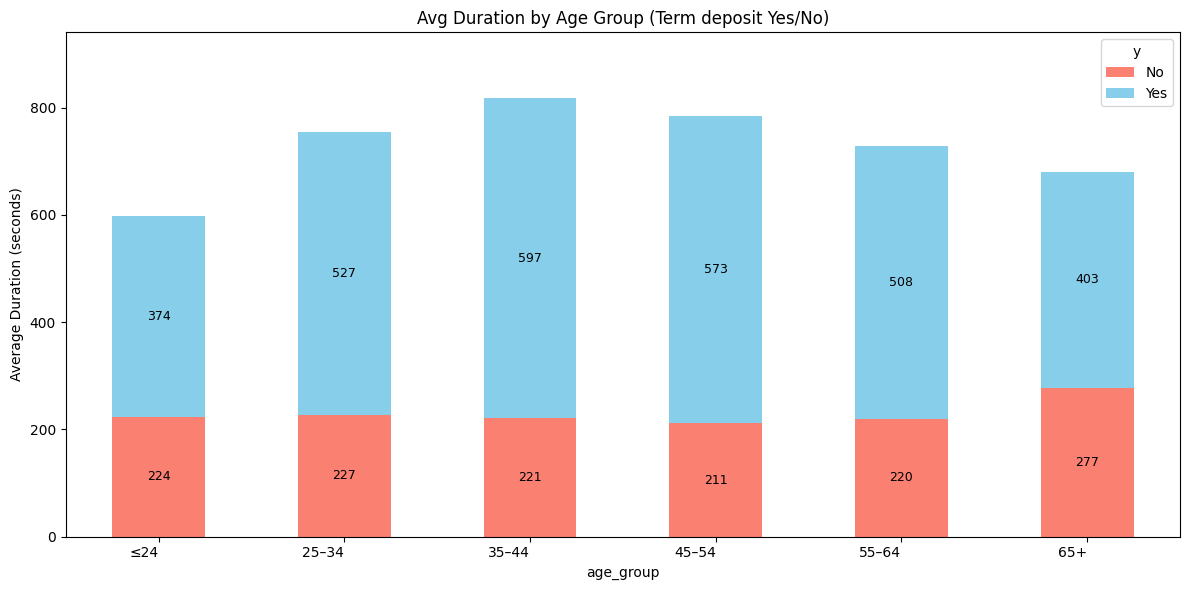

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------- helper: make age groups -------------
df3 = df.copy()
df3['age_group'] = pd.cut(
    df['age'],
    bins=[-np.inf, 24, 34, 44, 54, 64, np.inf],
    labels=['≤24','25–34','35–44','45–54','55–64','65+']
)

# ------------- helper: plotting function -------------
def stacked_mean_duration(df, by_col, title=None, figsize=(12,6), rotate=45):
    """
    Plots a stacked bar chart of average duration split by y (no/yes) for categories in by_col.
    """
    # compute mean duration by category and y
    means = (df3
             .groupby([by_col, 'y'])['duration']
             .mean()
             .unstack(fill_value=0)
             .reindex(columns=['no','yes'], fill_value=0))  # ensure order

    # keep category order deterministic
    means = means.sort_index()

    ax = means.plot(kind='bar', stacked=True, figsize=figsize, color=['salmon','skyblue'])

    ax.set_ylabel('Average Duration (seconds)')
    ax.set_title(title if title else f"Average Duration by {by_col} (stacked by y)")
    ax.set_ylim(0, max(1, (means.sum(axis=1).max() * 1.15)))
    plt.xticks(rotation=rotate, ha='right')
    plt.legend(title='y', labels=['No','Yes'])

    # add labels inside each stack
    for i, cat in enumerate(means.index):
        bottom = 0
        for col in ['no','yes']:
            val = means.loc[cat, col]
            if val > 0:
                ax.text(i, bottom + val/2, f"{val:.0f}", ha='center', va='center', fontsize=9)
            bottom += val

    plt.tight_layout()
    plt.show()

# ------------- make the four charts -------------
stacked_mean_duration(df3, 'job',        title="Avg Duration by Job (Term deposit Yes/No)", rotate=90, figsize=(14,6))
stacked_mean_duration(df3, 'education',  title="Avg Duration by Education (Term deposit Yes/No)", rotate=0)
stacked_mean_duration(df3, 'marital',    title="Avg Duration by Marital (Term deposit Yes/No)", rotate=0)
stacked_mean_duration(df3, 'age_group',  title="Avg Duration by Age Group (Term deposit Yes/No)", rotate=0)


/tmp/ipykernel_488448/337012977.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['age_bin', 'y']).size().unstack(fill_value=0)


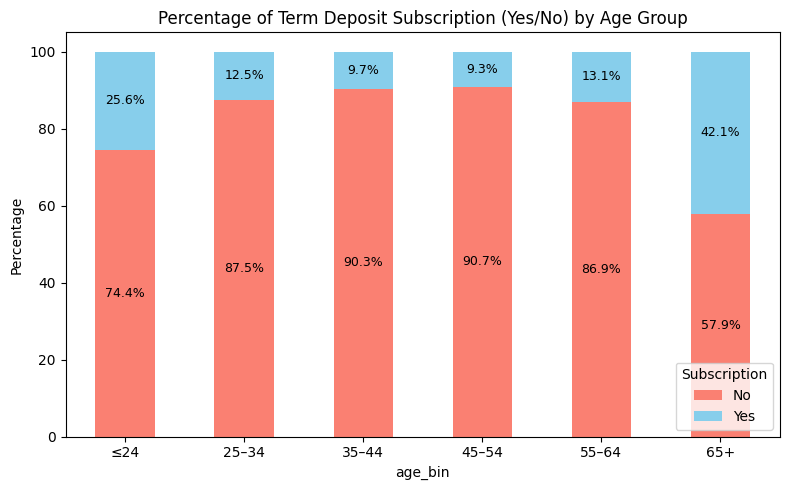

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Create age bins ---
df = df.copy()
df['age_bin'] = pd.cut(
    df['age'],
    bins=[-np.inf, 24, 34, 44, 54, 64, np.inf],
    labels=['≤24','25–34','35–44','45–54','55–64','65+']
)

# --- Count Yes/No by age bin ---
counts = df.groupby(['age_bin', 'y']).size().unstack(fill_value=0)

# --- Convert to percentages ---
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages = percentages[['no', 'yes']]  # keep order

# --- Plot stacked bar chart ---
ax = percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['salmon','skyblue']
)

plt.ylabel('Percentage')
plt.title("Percentage of Term Deposit Subscription (Yes/No) by Age Group")
plt.xticks(rotation=0)
plt.legend(title='Subscription', labels=['No','Yes'], loc='lower right')

# --- Add % labels inside bars ---
for i, age_group in enumerate(percentages.index):
    bottom = 0
    for outcome in ['no','yes']:
        val = percentages.loc[age_group, outcome]
        if val > 0:
            ax.text(i, bottom + val/2, f"{val:.1f}%", 
                    ha='center', va='center', fontsize=9, color='black')
        bottom += val

plt.tight_layout()
plt.show()



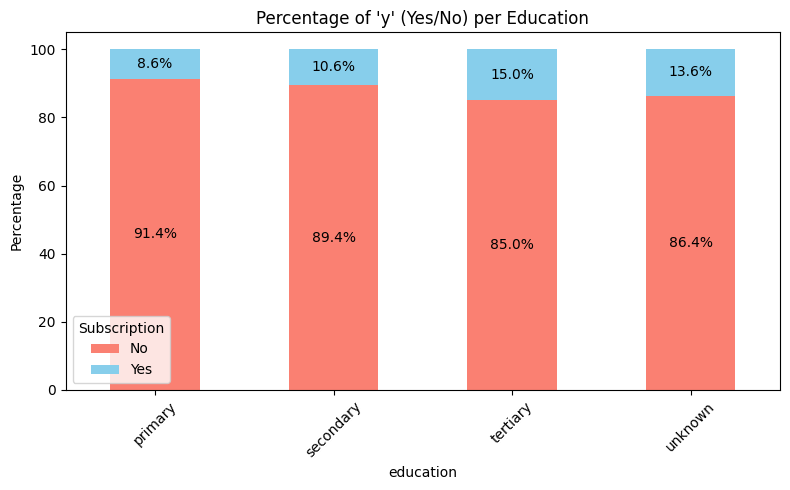

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Count yes/no per education
counts = df.groupby(['education', 'y']).size().unstack(fill_value=0)

# Convert to percentages
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = percentages.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=['salmon', 'skyblue']
)

plt.ylabel('Percentage')
plt.title("Percentage of 'y' (Yes/No) per Education")
plt.xticks(rotation=45)
plt.legend(title='Subscription', labels=['No', 'Yes'])

# Add % labels on each stacked segment
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.tight_layout()
plt.show()


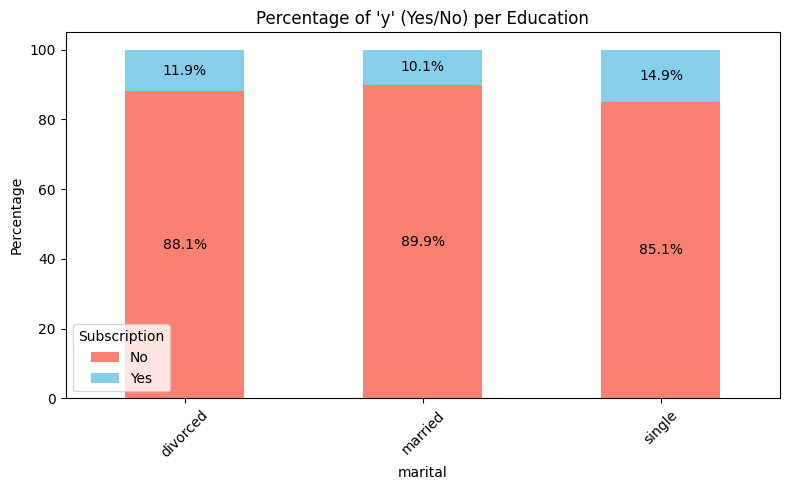

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Count yes/no per education
counts = df.groupby(['marital', 'y']).size().unstack(fill_value=0)

# Convert to percentages
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = percentages.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=['salmon', 'skyblue']
)

plt.ylabel('Percentage')
plt.title("Percentage of 'y' (Yes/No) per Education")
plt.xticks(rotation=45)
plt.legend(title='Subscription', labels=['No', 'Yes'])

# Add % labels on each stacked segment
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.tight_layout()
plt.show()


/tmp/ipykernel_445325/3398149066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['month','y']).size().unstack(fill_value=0)


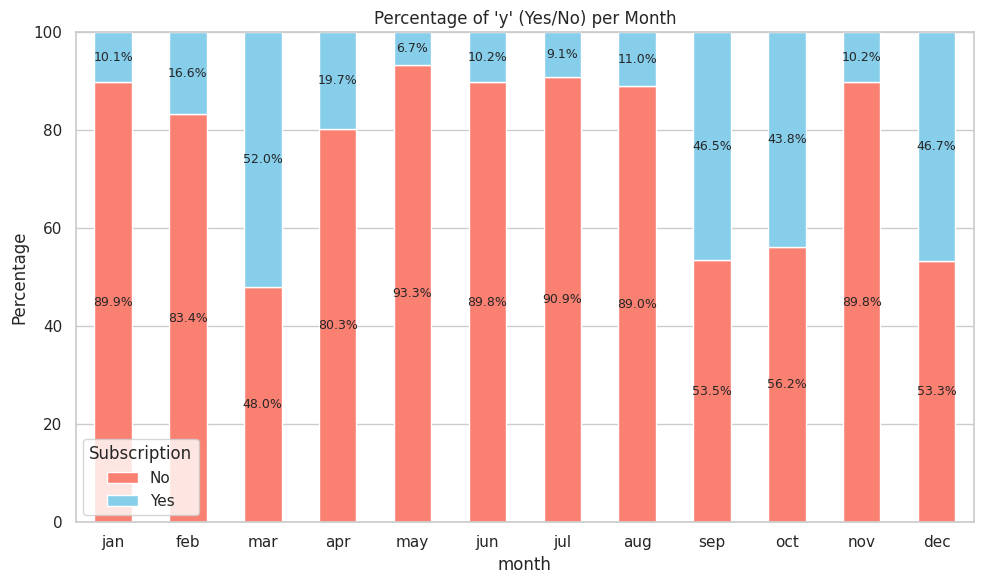

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Force month order Jan→Dec
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# 2) Count Yes/No per month
counts = df.groupby(['month','y']).size().unstack(fill_value=0)

# Ensure both columns exist (even if one is missing in data)
for col in ['no','yes']:
    if col not in counts.columns:
        counts[col] = 0

# 3) Convert to % and reindex to include all months
percentages = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100
percentages = percentages.reindex(month_order).fillna(0)  # keep all months on x-axis

# 4) Plot stacked bar
ax = percentages[['no','yes']].plot(kind='bar', stacked=True, figsize=(10,6),
                                    color=['salmon','skyblue'])
ax.set_ylim(0, 100)
plt.ylabel('Percentage')
plt.title("Percentage of 'y' (Yes/No) per Month")
plt.xticks(rotation=0)
plt.legend(title='Subscription', labels=['No','Yes'])

# 5) Label each stacked segment with its percentage
for i, month in enumerate(percentages.index):
    bottom = 0
    for col in ['no','yes']:
        val = percentages.loc[month, col]
        if val > 0:
            ax.text(i, bottom + val/2, f"{val:.1f}%", ha='center', va='center', fontsize=9)
        bottom += val

plt.tight_layout()
plt.show()


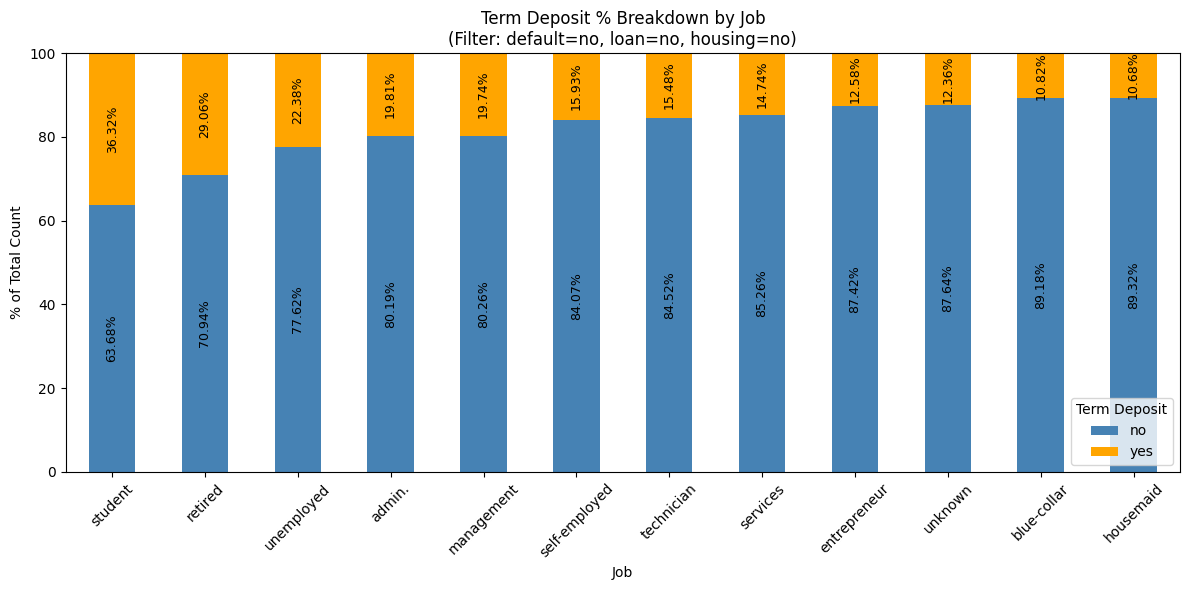

In [17]:
import matplotlib.pyplot as plt

# 1. Filter dataset
df_filtered = df[(df['default'] == 'no') &
                 (df['loan'] == 'no') &
                 (df['housing'] == 'no')]

# 2. Group by job and y
job_counts = df_filtered.groupby(['job', 'y']).size().unstack(fill_value=0)

# 3. Convert counts to percentages
job_perc = job_counts.div(job_counts.sum(axis=1), axis=0) * 100

# 4. Keep correct order and sort by 'yes' %
job_perc = job_perc[['no', 'yes']].sort_values(by='yes', ascending=False)

# 5. Plot stacked bar
fig, ax = plt.subplots(figsize=(12,6))
job_perc.plot(kind='bar', stacked=True, color=['steelblue', 'orange'], ax=ax)

# 6. Add % labels inside bars (vertical like Tableau)
for i, row in enumerate(job_perc.itertuples()):
    no_val = row.no
    yes_val = row.yes
    
    # "no" section
    ax.text(i, no_val / 2, f"{no_val:.2f}%", ha='center', va='center',
            color='black', fontsize=9, rotation=90)
    
    # "yes" section
    ax.text(i, no_val + (yes_val / 2), f"{yes_val:.2f}%", ha='center', va='center',
            color='black', fontsize=9, rotation=90)

# 7. Formatting
ax.set_ylabel('% of Total Count')
ax.set_xlabel('Job')
ax.set_title('Term Deposit % Breakdown by Job\n(Filter: default=no, loan=no, housing=no)')
ax.legend(title='Term Deposit', loc='lower right')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


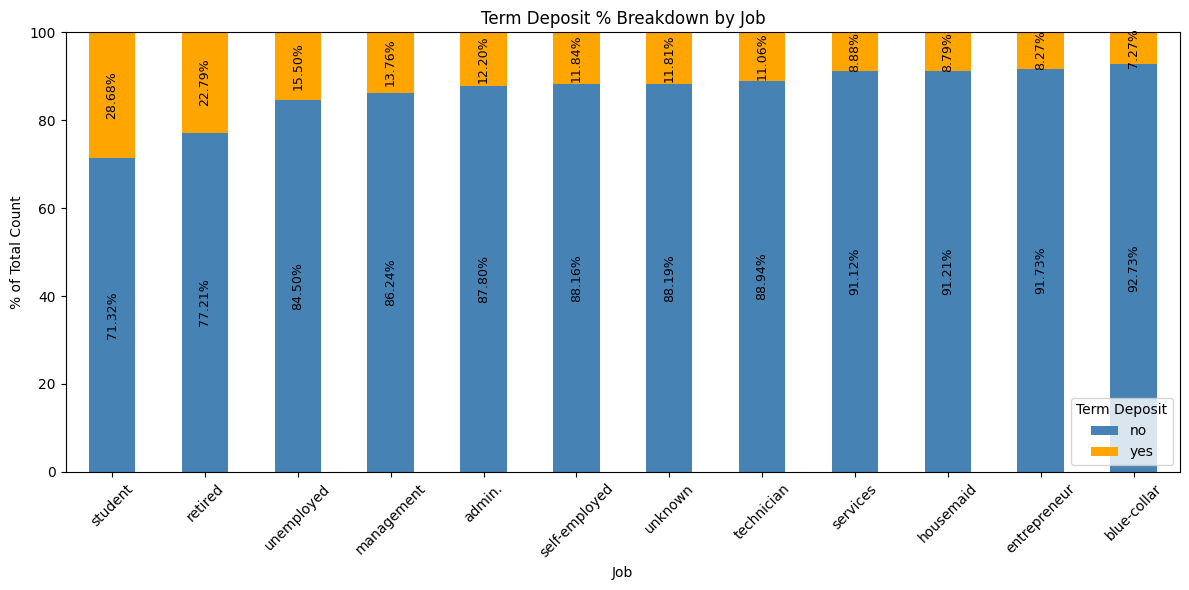

In [4]:
import matplotlib.pyplot as plt


# 2. Group by job and y
job_counts = df.groupby(['job', 'y']).size().unstack(fill_value=0)

# 3. Convert counts to percentages
job_perc = job_counts.div(job_counts.sum(axis=1), axis=0) * 100

# 4. Keep correct order and sort by 'yes' %
job_perc = job_perc[['no', 'yes']].sort_values(by='yes', ascending=False)

# 5. Plot stacked bar
fig, ax = plt.subplots(figsize=(12,6))
job_perc.plot(kind='bar', stacked=True, color=['steelblue', 'orange'], ax=ax)

# 6. Add % labels inside bars (vertical like Tableau)
for i, row in enumerate(job_perc.itertuples()):
    no_val = row.no
    yes_val = row.yes
    
    # "no" section
    ax.text(i, no_val / 2, f"{no_val:.2f}%", ha='center', va='center',
            color='black', fontsize=9, rotation=90)
    
    # "yes" section
    ax.text(i, no_val + (yes_val / 2), f"{yes_val:.2f}%", ha='center', va='center',
            color='black', fontsize=9, rotation=90)

# 7. Formatting
ax.set_ylabel('% of Total Count')
ax.set_xlabel('Job')
ax.set_title('Term Deposit % Breakdown by Job')
ax.legend(title='Term Deposit', loc='lower right')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [27]:
df2 = df.copy()


In [28]:
import statsmodels.api as sm
from patsy import dmatrices

# Convert target to binary numeric
df2['y_binary'] = df2['y'].map({'no': 0, 'yes': 1})

# Formula (categorical vars wrapped in C())
formula = 'y_binary ~ age + C(job) + C(marital) + C(education) + default + balance + housing + loan + C(contact) + day + C(month) + duration + campaign + pdays + previous + C(poutcome)'

# Create design matrices
y, X = dmatrices(formula, data=df2, return_type='dataframe')

# Convert y to 1D
y = y['y_binary']

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())




Optimization terminated successfully.
         Current function value: 0.238463
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               y_binary   No. Observations:                45211
Model:                          Logit   Df Residuals:                    45168
Method:                           MLE   Df Model:                           42
Date:                Fri, 15 Aug 2025   Pseudo R-squ.:                  0.3392
Time:                        19:39:49   Log-Likelihood:                -10781.
converged:                       True   LL-Null:                       -16315.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -3.7974      0.208    -18.213      0.000      -4.

In [29]:
# Get p-values and coefficients
summary_df = pd.DataFrame({
    'feature': result.params.index,
    'coef': result.params.values,
    'p_value': result.pvalues.values
})

# Sort by p-value (ascending: most significant first)
summary_df = summary_df.sort_values(by='p_value')

print(summary_df)


                      feature      coef        p_value
39                   duration  0.004194   0.000000e+00
34     C(poutcome)[T.success]  2.291056  2.401599e-170
21      C(contact)[T.unknown] -1.623217  5.001575e-109
23            C(month)[T.mar]  2.851609   2.554280e-78
0                   Intercept -3.797357   4.087357e-74
18             housing[T.yes] -0.675384   1.759225e-53
30            C(month)[T.oct]  2.143156   3.907996e-52
29            C(month)[T.sep]  2.135777   9.617544e-45
26            C(month)[T.jun]  1.715341   2.106338e-37
24            C(month)[T.apr]  1.261719   3.497104e-25
32            C(month)[T.dec]  1.952843   1.262857e-22
40                   campaign -0.090782   3.392796e-19
22            C(month)[T.feb]  1.114398   3.324458e-17
25            C(month)[T.may]  0.862607   9.966486e-13
19                loan[T.yes] -0.425372   1.334860e-12
15   C(education)[T.tertiary]  0.378942   4.876664e-07
28            C(month)[T.aug]  0.567811   2.755952e-06
1       C(

/tmp/ipykernel_445325/4055704172.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_counts = df.groupby(['month', 'y']).size().unstack(fill_value=0)


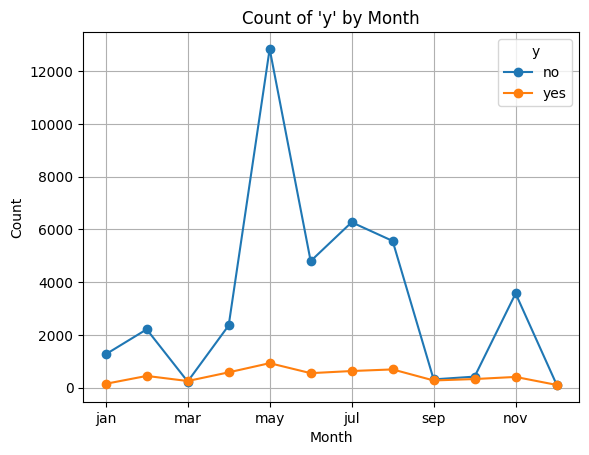

In [7]:
import matplotlib.pyplot as plt

# Ensure month is in the correct order
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Group and count
month_counts = df.groupby(['month', 'y']).size().unstack(fill_value=0)

# Plot
month_counts.plot(kind='line', marker='o')
plt.title("Count of 'y' by Month")
plt.ylabel("Count")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [14]:
!pip install statsmodels


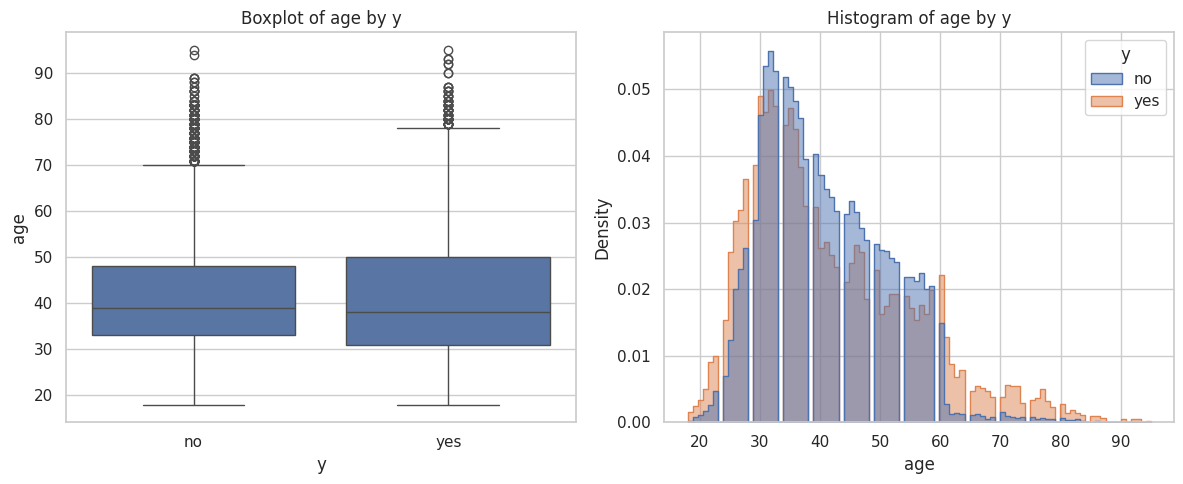

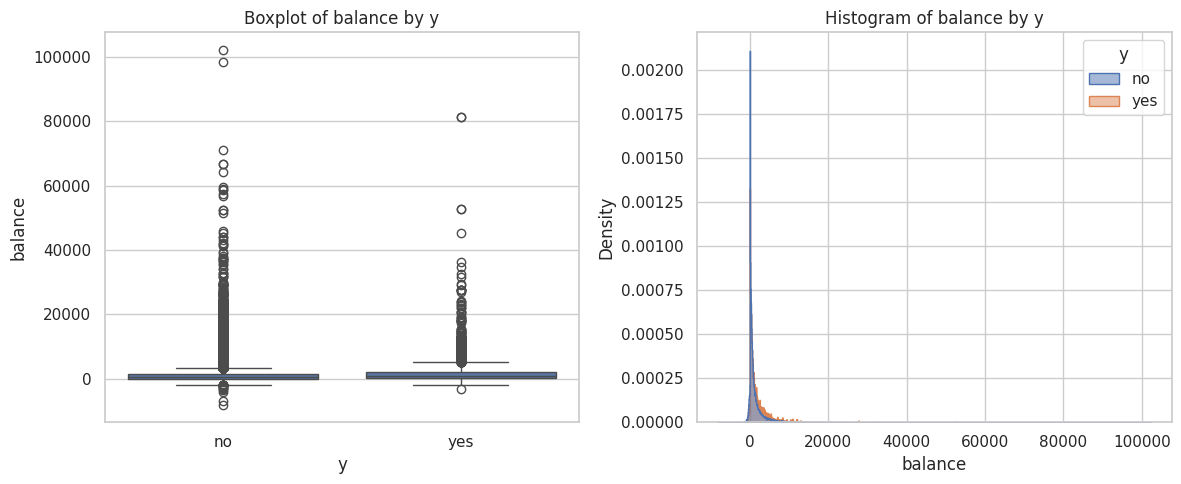

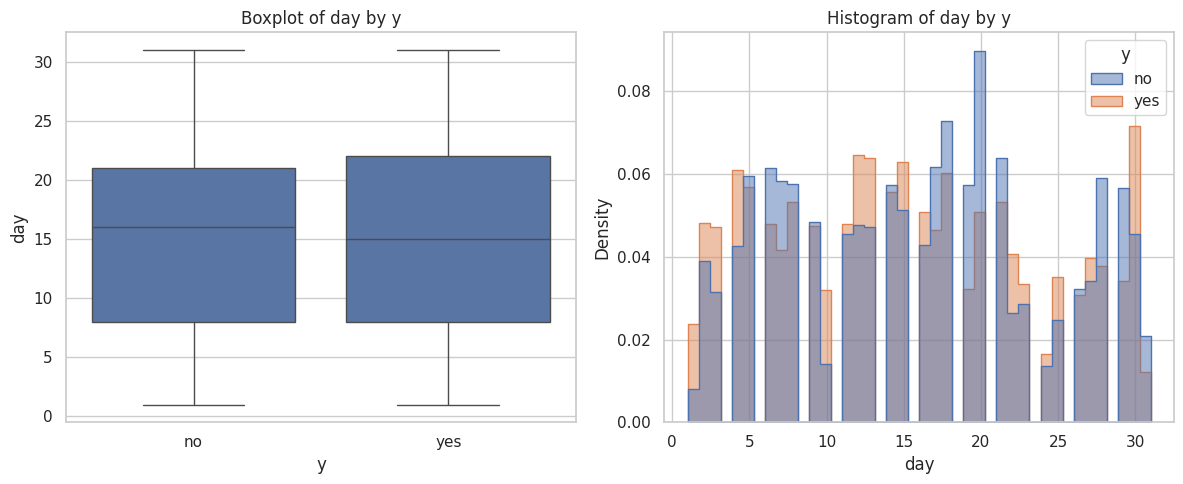

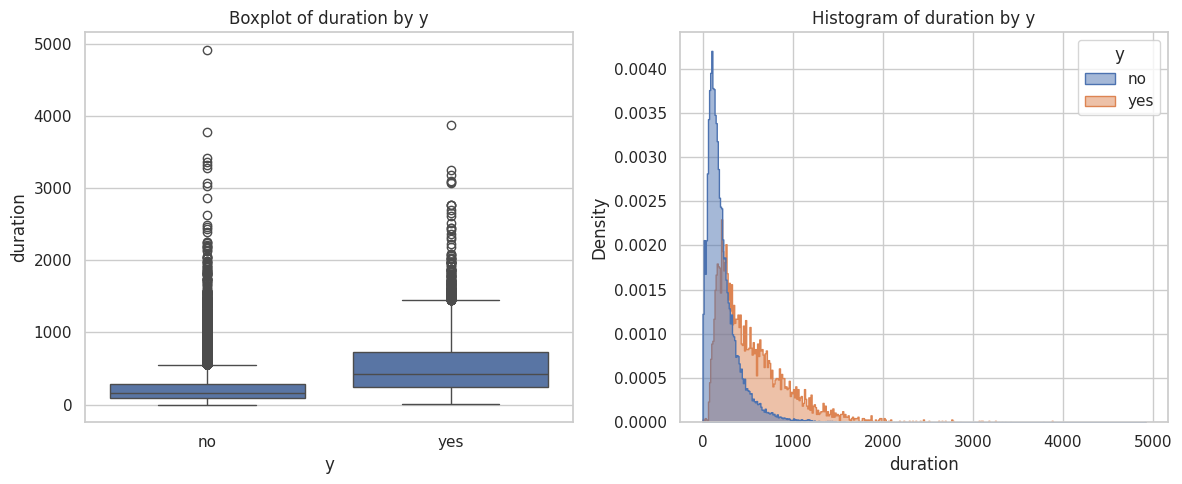

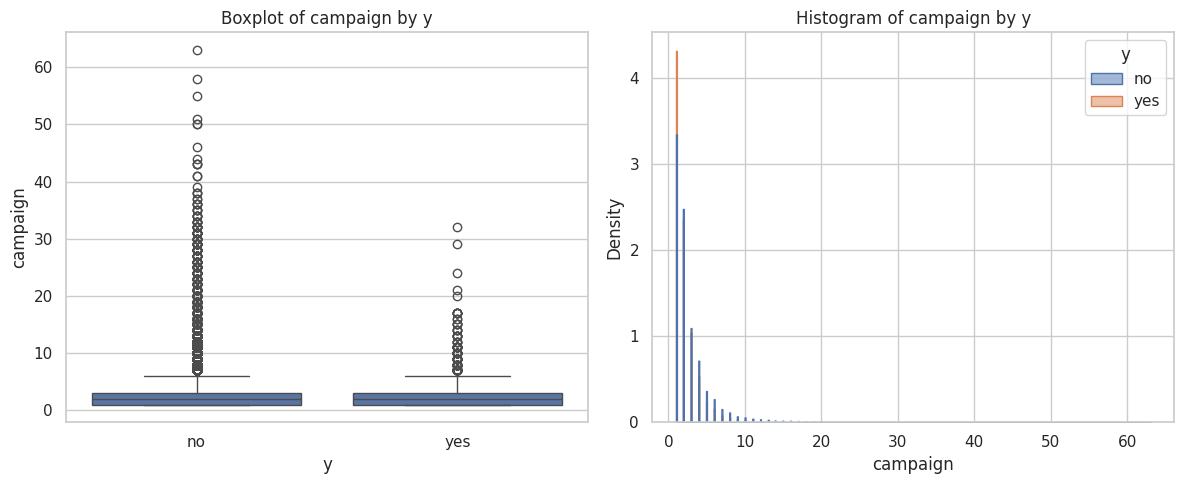

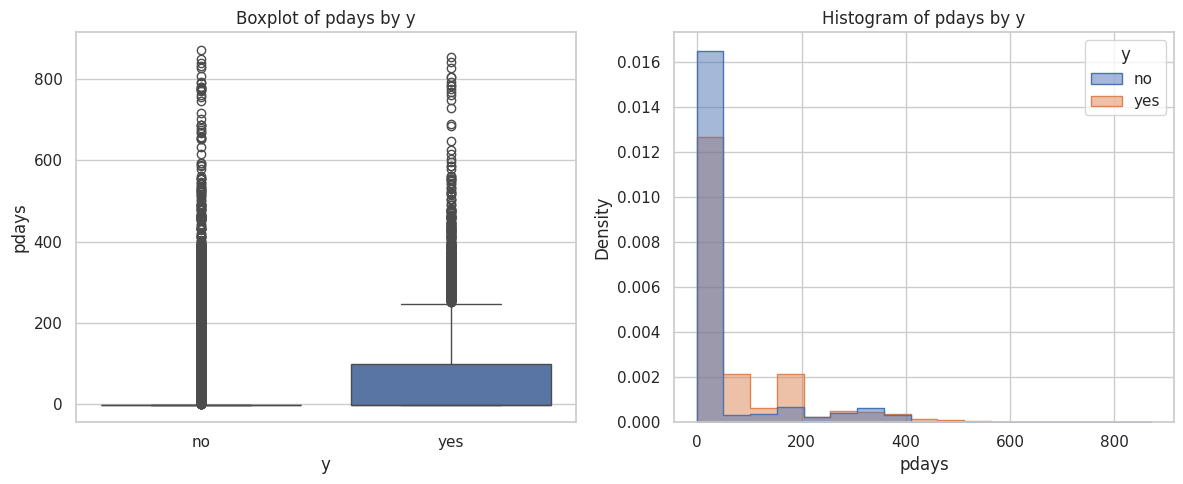

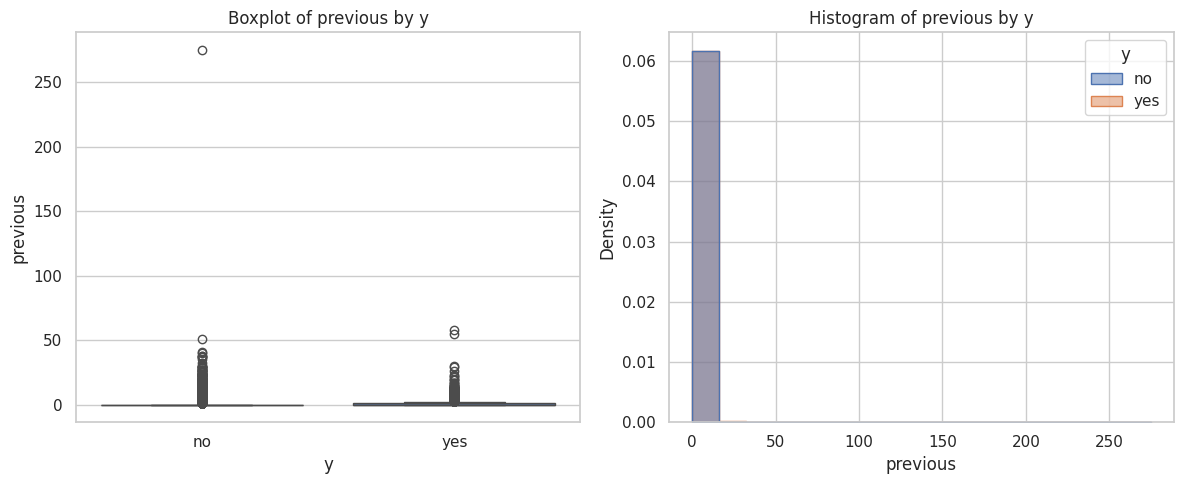

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to visualize
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Set up plotting style
sns.set(style="whitegrid")

for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Boxplot split by y
    plt.subplot(1, 2, 1)
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'Boxplot of {col} by y')

    # Histogram split by y (with transparency)
    plt.subplot(1, 2, 2)
    sns.histplot(data=df, x=col, hue='y', element='step', stat='density', common_norm=False, alpha=0.5)
    plt.title(f'Histogram of {col} by y')

    plt.tight_layout()
    plt.show()


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline  # sklearn's standard pipeline since no SMOTE
import numpy as np
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, classification_report, balanced_accuracy_score
)

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, feature selection (Lasso), classifier (Logistic Regression)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
        threshold='mean'  # keep features with coefficients above average magnitude
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluate - Accuracy, Recall, Precision, F1
print("=== Train Scores ===")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:  {f1_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.3f}")

# Detailed classification report for test set
print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


=== Train Scores ===
Accuracy:  0.902
Recall:    0.341
Precision: 0.652
F1 Score:  0.448

=== Validation Scores ===
Accuracy:  0.902
Recall:    0.344
Precision: 0.654
F1 Score:  0.451

=== Test Scores ===
Accuracy:  0.901
Recall:    0.339
Precision: 0.645
F1 Score:  0.445

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.64      0.34      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [10]:
!pip install --upgrade scikit-learn imbalanced-learn


In [11]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier

#Feature Selection: pick the most important features automatically using a simple Logistic Regression model with L1 regularization (which shrinks less important feature coefficients to zero).

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        LogisticRegression(
            penalty='l1', solver='liblinear', max_iter=2000, C=0.5, random_state=42
        ),
        threshold='mean'
    )),
    ('classifier', LogisticRegression(max_iter=2000, C=0.5, random_state=42))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)


# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


##SMOTE helps when one group is much smaller than the other. By creating synthetic (fake but realistic) examples for the smaller group, SMOTE balances the data so models can learn better and not get biased toward the larger group.


=== Train Scores ===
Accuracy:          0.847
Recall:            0.799
Precision:         0.420
F1 Score:          0.551
Balanced Accuracy: 0.826

=== Validation Scores ===
Accuracy:          0.846
Recall:            0.803
Precision:         0.417
F1 Score:          0.549
Balanced Accuracy: 0.827

=== Test Scores ===
Accuracy:          0.845
Recall:            0.799
Precision:         0.416
F1 Score:          0.547
Balanced Accuracy: 0.825

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.80      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.90      0.85      0.86      9043



Test ROC AUC: 0.901


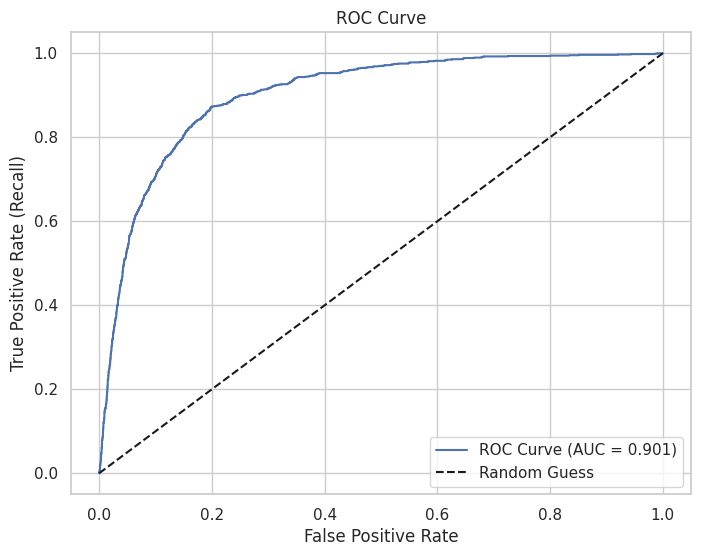

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class (1)
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate AUC
test_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test ROC AUC: {test_auc:.3f}")

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
## model's curve staying well above the diagonal and near the top-left corner indicates strong predictive performance.

In [12]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [13]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)


# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)




# Pipeline with SMOTE + XGBoost
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluation (same as before)
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:41:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Train Scores ===
Accuracy:          0.918
Recall:            0.627
Precision:         0.659
F1 Score:          0.643
Balanced Accuracy: 0.792

=== Validation Scores ===
Accuracy:          0.906
Recall:            0.584
Precision:         0.600
F1 Score:          0.592
Balanced Accuracy: 0.766

=== Test Scores ===
Accuracy:          0.905
Recall:            0.564
Precision:         0.602
F1 Score:          0.583
Balanced Accuracy: 0.757

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7985
           1       0.60      0.56      0.58      1058

    accuracy                           0.91      9043
   macro avg       0.77      0.76      0.76      9043
weighted avg       0.90      0.91      0.90      9043



In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier

#Feature Selection: pick the most important features automatically using a simple Logistic Regression model with L1 regularization (which shrinks less important feature coefficients to zero).

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        LogisticRegression(
            penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42
        ),
        threshold='mean'
    )),
    ('classifier', LogisticRegression(max_iter=5000, C=0.5, random_state=42))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)

# Get selected features
# Step 1: Get all transformed feature names
num_features_transformed = num_features
cat_features_transformed = list(
    pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
)
all_transformed_features = num_features_transformed + cat_features_transformed

# Step 2: Get boolean mask of selected features
selected_mask = pipeline.named_steps['feature_selection'].get_support()

# Step 3: Apply mask to get selected feature names
selected_features = np.array(all_transformed_features)[selected_mask]

# Step 4: Print selected features
print("\n=== Selected Features ===")
print(selected_features)




# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


In [14]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'age']
cat_features = ['job','default','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier

#Feature Selection: pick the most important features automatically using a simple Logistic Regression model with L1 regularization (which shrinks less important feature coefficients to zero).

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        penalty='l1',        # L1 regularization
        solver='saga',       # required for L1
        max_iter=5000,
        C=0.5,
        random_state=42
    ))
])


# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


=== Train Scores ===
Accuracy:          0.846
Recall:            0.814
Precision:         0.419
F1 Score:          0.553
Balanced Accuracy: 0.832

=== Validation Scores ===
Accuracy:          0.843
Recall:            0.808
Precision:         0.412
F1 Score:          0.546
Balanced Accuracy: 0.828

=== Test Scores ===
Accuracy:          0.847
Recall:            0.806
Precision:         0.419
F1 Score:          0.552
Balanced Accuracy: 0.829

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



In [15]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'age']
cat_features = ['job','default','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        objective='binary:logistic',  # binary classification
        eval_metric='logloss',        # evaluation metric
        use_label_encoder=False,
        reg_alpha=0.5,                # L1 regularization
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    ))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [18:41:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Train Scores ===
Accuracy:          0.902
Recall:            0.713
Precision:         0.566
F1 Score:          0.631
Balanced Accuracy: 0.820

=== Validation Scores ===
Accuracy:          0.890
Recall:            0.664
Precision:         0.522
F1 Score:          0.585
Balanced Accuracy: 0.792

=== Test Scores ===
Accuracy:          0.890
Recall:            0.658
Precision:         0.525
F1 Score:          0.584
Balanced Accuracy: 0.790

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      7985
           1       0.53      0.66      0.58      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.79      0.76      9043
weighted avg       0.90      0.89      0.90      9043



In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'campaign','day']
cat_features = ['job','default','education','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        reg_alpha=2,       # L1 regularization ↑ (default 0)
        reg_lambda=5,      # L2 regularization ↑ (default 1)
        random_state=42
    ))
])

# Train model



pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


=== Train Scores ===
Accuracy:          0.847
Recall:            0.813
Precision:         0.421
F1 Score:          0.555
Balanced Accuracy: 0.832

=== Validation Scores ===
Accuracy:          0.845
Recall:            0.818
Precision:         0.417
F1 Score:          0.553
Balanced Accuracy: 0.833

=== Test Scores ===
Accuracy:          0.846
Recall:            0.811
Precision:         0.419
F1 Score:          0.553
Balanced Accuracy: 0.831

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



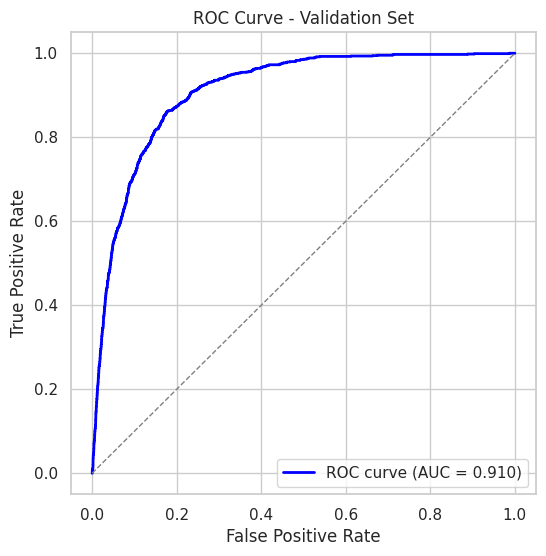

ROC AUC (Train): 0.908
ROC AUC (Validation): 0.910
ROC AUC (Test): 0.907


In [16]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'campaign','day']
cat_features = ['job','default','education','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier



#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        penalty='l1',        # L1 regularization
        solver='saga',       # required for L1
        max_iter=5000,
        C=0.5,
        random_state=42
    ))
])


# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))



import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# ROC Curve for the validation set
y_val_proba = pipeline.predict_proba(X_val)[:, 1]  # Probabilities for class 1
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Also print numeric ROC AUC scores
print(f"ROC AUC (Train): {roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1]):.3f}")
print(f"ROC AUC (Validation): {roc_auc_score(y_val, y_val_proba):.3f}")
print(f"ROC AUC (Test): {roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1]):.3f}")







=== Train Scores ===
Accuracy:          0.911
Recall:            0.776
Precision:         0.591
F1 Score:          0.671
Balanced Accuracy: 0.853
ROC AUC:           0.949

=== Validation Scores ===
Accuracy:          0.894
Recall:            0.714
Precision:         0.535
F1 Score:          0.611
Balanced Accuracy: 0.816
ROC AUC:           0.931

=== Test Scores ===
Accuracy:          0.892
Recall:            0.700
Precision:         0.530
F1 Score:          0.603
Balanced Accuracy: 0.809
ROC AUC:           0.923

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      7985
           1       0.53      0.70      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.81      0.77      9043
weighted avg       0.91      0.89      0.90      9043



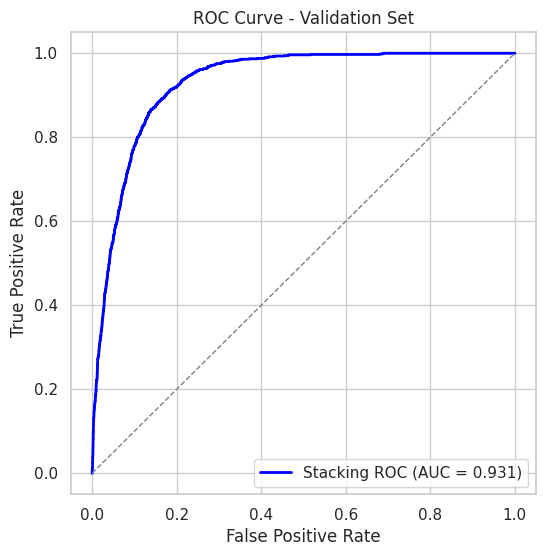

In [22]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['balance', 'duration', 'campaign', 'day']
cat_features = ['job', 'default', 'education', 'loan', 'housing', 'contact', 'month', 'poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Split data
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Base models
log_reg_base = LogisticRegression(
    penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42
)
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42
)
xgb_base = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, eval_metric='logloss', random_state=42
)

# Meta-model
meta_model = LogisticRegression(
    penalty='l1', solver='saga', C=1.0, max_iter=5000, random_state=42
)

# Stacking ensemble
stacking_clf = StackingClassifier(
    estimators=[
        ('log_reg', log_reg_base),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=False,  # Set to True if you want original features fed to meta-model too
    cv=5,
    n_jobs=-1
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', stacking_clf)
])

# Train
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluation function
def evaluate_model(split, y_true, y_pred, y_proba):
    print(f"\n=== {split} Scores ===")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, y_proba):.3f}")

# Evaluate
evaluate_model("Train", y_train, y_train_pred, pipeline.predict_proba(X_train)[:, 1])
evaluate_model("Validation", y_val, y_val_pred, pipeline.predict_proba(X_val)[:, 1])
evaluate_model("Test", y_test, y_test_pred, pipeline.predict_proba(X_test)[:, 1])

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))

# ROC curve plot
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Stacking ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



=== Train Scores ===
Accuracy:          0.911
Recall:            0.788
Precision:         0.591
F1 Score:          0.675
Balanced Accuracy: 0.858
ROC AUC:           0.951

=== Validation Scores ===
Accuracy:          0.893
Recall:            0.721
Precision:         0.530
F1 Score:          0.611
Balanced Accuracy: 0.818
ROC AUC:           0.931

=== Test Scores ===
Accuracy:          0.890
Recall:            0.712
Precision:         0.521
F1 Score:          0.602
Balanced Accuracy: 0.813
ROC AUC:           0.925

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      7985
           1       0.52      0.71      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.81      0.77      9043
weighted avg       0.91      0.89      0.90      9043



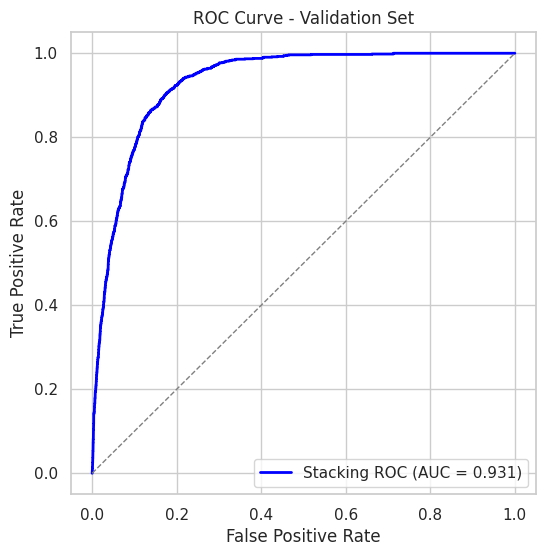

In [17]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['balance', 'duration', 'campaign', 'day','pdays','previous']
cat_features = ['job', 'default', 'education', 'loan', 'housing', 'contact', 'month', 'poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Split data
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Base models
log_reg_base = LogisticRegression(
    penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42
)
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42
)
xgb_base = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, eval_metric='logloss', random_state=42
)

# Meta-model
meta_model = LogisticRegression(
    penalty='l1', solver='saga', C=1.0, max_iter=5000, random_state=42
)

# Stacking ensemble
stacking_clf = StackingClassifier(
    estimators=[
        ('log_reg', log_reg_base),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=False,  # Set to True if you want original features fed to meta-model too
    cv=5,
    n_jobs=-1
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', stacking_clf)
])

# Train
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluation function
def evaluate_model(split, y_true, y_pred, y_proba):
    print(f"\n=== {split} Scores ===")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, y_proba):.3f}")

# Evaluate
evaluate_model("Train", y_train, y_train_pred, pipeline.predict_proba(X_train)[:, 1])
evaluate_model("Validation", y_val, y_val_pred, pipeline.predict_proba(X_val)[:, 1])
evaluate_model("Test", y_test, y_test_pred, pipeline.predict_proba(X_test)[:, 1])

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))

# ROC curve plot
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Stacking ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



=== Train Scores ===
Accuracy:          0.911
Recall:            0.788
Precision:         0.591
F1 Score:          0.675
Balanced Accuracy: 0.858
ROC AUC:           0.951

=== Validation Scores ===
Accuracy:          0.893
Recall:            0.721
Precision:         0.530
F1 Score:          0.611
Balanced Accuracy: 0.818
ROC AUC:           0.931

=== Test Scores ===
Accuracy:          0.890
Recall:            0.712
Precision:         0.521
F1 Score:          0.602
Balanced Accuracy: 0.813
ROC AUC:           0.925

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      7985
           1       0.52      0.71      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.81      0.77      9043
weighted avg       0.91      0.89      0.90      9043



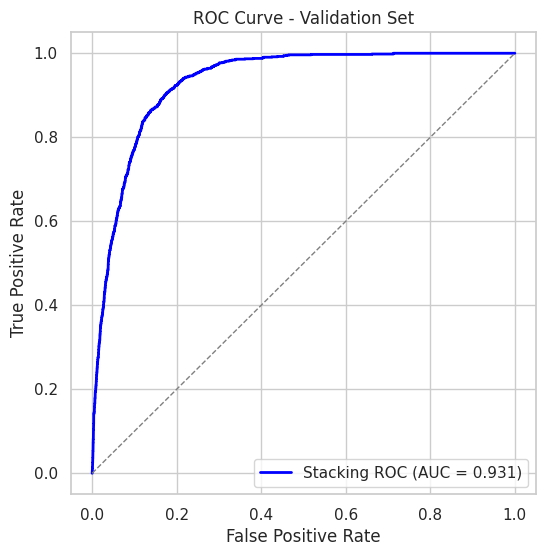

In [18]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['balance', 'duration', 'campaign', 'day','pdays','previous']
cat_features = ['job', 'default', 'education', 'loan', 'housing', 'contact', 'month', 'poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Split data
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Base models
log_reg_base = LogisticRegression(
    penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42
)
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42
)
xgb_base = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, eval_metric='logloss', random_state=42
)

# Meta-model
meta_model = LogisticRegression(
    penalty='l1', solver='saga', C=1.0, max_iter=5000, random_state=42
)

# Stacking ensemble
stacking_clf = StackingClassifier(
    estimators=[
        ('log_reg', log_reg_base),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=False,  # Set to True if you want original features fed to meta-model too
    cv=5,
    n_jobs=-1
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', stacking_clf)
])

# Train
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluation function
def evaluate_model(split, y_true, y_pred, y_proba):
    print(f"\n=== {split} Scores ===")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, y_proba):.3f}")

# Evaluate
evaluate_model("Train", y_train, y_train_pred, pipeline.predict_proba(X_train)[:, 1])
evaluate_model("Validation", y_val, y_val_pred, pipeline.predict_proba(X_val)[:, 1])
evaluate_model("Test", y_test, y_test_pred, pipeline.predict_proba(X_test)[:, 1])

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))

# ROC curve plot
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Stacking ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



=== Train Scores ===
Accuracy:          0.930
Recall:            0.698
Precision:         0.705
F1 Score:          0.701
Balanced Accuracy: 0.830
ROC AUC:           0.959

=== Validation Scores ===
Accuracy:          0.906
Recall:            0.603
Precision:         0.596
F1 Score:          0.600
Balanced Accuracy: 0.774
ROC AUC:           0.934

=== Test Scores ===
Accuracy:          0.904
Recall:            0.584
Precision:         0.593
F1 Score:          0.589
Balanced Accuracy: 0.766
ROC AUC:           0.925

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7985
           1       0.59      0.58      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.77      0.77      9043
weighted avg       0.90      0.90      0.90      9043



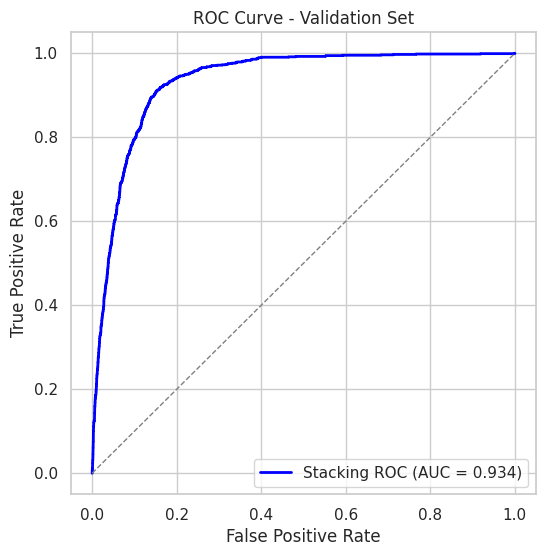

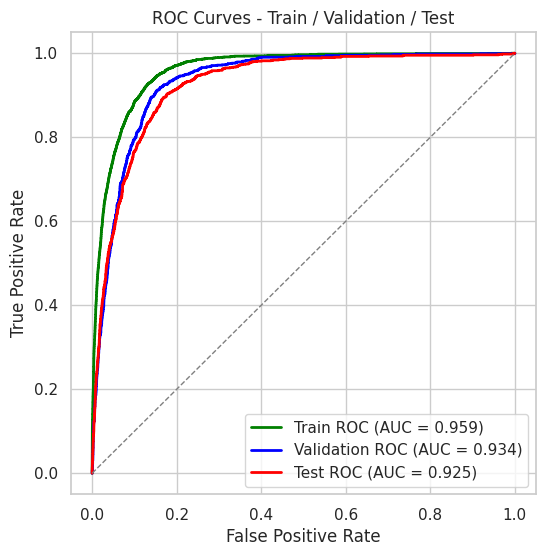

In [24]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    balanced_accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['balance', 'duration', 'campaign', 'day','pdays','previous']
cat_features = ['job', 'default', 'education', 'loan', 'housing', 'contact', 'month', 'poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Split data
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Base models
log_reg_base = LogisticRegression(
    penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42
)
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=10, random_state=42
)
xgb_base = XGBClassifier(
    n_estimators=300, learning_rate=0.08, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, eval_metric='logloss', random_state=42
)
gb_base = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.08, max_depth=5, random_state=42
)

# Meta-model
meta_model = LogisticRegression(
    penalty='l2', solver='lbfgs', max_iter=5000, C=1.0, random_state=42
    
)

# Stacking ensemble with stratified CV
stacking_clf = StackingClassifier(
    estimators=[
        ('log_reg', log_reg_base),
        ('rf', rf_base),
        ('xgb', xgb_base),
        ('gb', gb_base)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=False,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

# Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.8)),
    ('classifier', stacking_clf)
])

# Train
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluation function
def evaluate_model(split, y_true, y_pred, y_proba):
    print(f"\n=== {split} Scores ===")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")
    print(f"ROC AUC:           {roc_auc_score(y_true, y_proba):.3f}")

# Evaluate
evaluate_model("Train", y_train, y_train_pred, pipeline.predict_proba(X_train)[:, 1])
evaluate_model("Validation", y_val, y_val_pred, pipeline.predict_proba(X_val)[:, 1])
evaluate_model("Test", y_test, y_test_pred, pipeline.predict_proba(X_test)[:, 1])

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))

# ROC curve plot
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Stacking ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


# Get predicted probabilities
y_train_proba = pipeline.predict_proba(X_train)[:, 1]
y_val_proba = pipeline.predict_proba(X_val)[:, 1]
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

# Compute AUC
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot all ROC curves
plt.figure(figsize=(6, 6))
plt.plot(fpr_train, tpr_train, color='green', lw=2, label=f'Train ROC (AUC = {roc_auc_train:.3f})')
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation ROC (AUC = {roc_auc_val:.3f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test ROC (AUC = {roc_auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Train / Validation / Test')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [3]:
df4=df.copy()
df4.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [23]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  object  
 2   marital    45211 non-null  object  
 3   education  45211 non-null  object  
 4   default    45211 non-null  object  
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  object  
 7   loan       45211 non-null  object  
 8   contact    45211 non-null  object  
 9   day        45211 non-null  int64   
 10  month      45211 non-null  object  
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  object  
 16  y          45211 non-null  object  
 17  age_bin    45211 non-null  category
 18  cluster    45211 non-null  int32   
dtypes: category(1), int32(1),

In [7]:
import time
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

t0 = time.time()

# ---------------------------
# 1) Use all features except the target
# ---------------------------
assert 'y' in df4.columns, "Expected target column 'y' in df4"
X = df4.drop(columns=['y']).copy()

# Identify numeric vs categorical by dtype (robust)
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

# ---------------------------
# 2) Preprocessing pipelines
# ---------------------------
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# OneHotEncoder: force DENSE output across sklearn versions
try:
    cat_ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False)
except TypeError:
    cat_ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse=False)

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', cat_ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ],
    remainder='drop'
)

# ---------------------------
# 3) KMeans pipeline
# ---------------------------
kmeans_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clusterer', KMeans(n_clusters=4, n_init=10, random_state=42))
])

print("Fitting KMeans pipeline...")
kmeans_pipe.fit(X)
print("Done.")

# Attach clusters back to df4 (doesn't modify X)
df4['cluster'] = kmeans_pipe.named_steps['clusterer'].labels_

# ---------------------------
# 4) Quick sanity checks / summaries
# ---------------------------
print("\nCluster counts:")
print(df4['cluster'].value_counts().sort_index())

if num_features:
    print("\nNumeric means by cluster:")
    print(df4.groupby('cluster')[num_features].mean().round(2))

if cat_features:
    print("\nTop categorical proportions by cluster (first few columns):")
    for col in cat_features[:5]:  # show a few; expand as needed
        ctab = pd.crosstab(df4['cluster'], df4[col], normalize='index').round(3)
        print(f"\n{col} (row = cluster, values = % within cluster)")
        print(ctab)

print(f"\nElapsed: {time.time() - t0:.2f}s")


Fitting KMeans pipeline...
Done.

Cluster counts:
cluster
0    22026
1     7003
2     1631
3    14551
Name: count, dtype: int64

Numeric means by cluster:
           age  balance    day  duration  campaign   pdays  previous  cluster
cluster                                                                      
0        33.98   932.22  15.88    274.81      2.29    0.80      0.04      0.0
1        39.70  1440.63  14.17    257.41      2.09  248.19      3.41      1.0
2        40.27  1084.87  21.48    153.28     14.84   -0.16      0.02      2.0
3        52.14  2006.62  15.85    245.09      2.46    4.26      0.10      3.0

Top categorical proportions by cluster (first few columns):

job (row = cluster, values = % within cluster)
job      admin.  blue-collar  entrepreneur  housemaid  management  retired  \
cluster                                                                      
0         0.125        0.224         0.030      0.016       0.212    0.002   
1         0.137        0.219      

In [8]:
pd.crosstab(df4['cluster'], df4['y'], normalize='index') * 100


y,no,yes
cluster,,
0,89.544175,10.455825
1,79.822933,20.177067
2,96.750460,3.249540
3,89.553983,10.446017


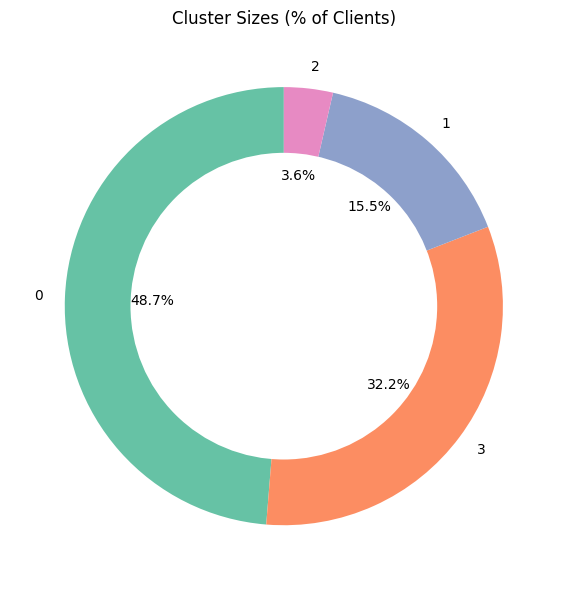

In [12]:
import matplotlib.pyplot as plt

# Cluster sizes
counts = df4['cluster'].value_counts()

# Create a pie chart
fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set2.colors,
    textprops=dict(color="black")
)

# Add a circle at the center to turn it into a doughnut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# Title
plt.title("Cluster Sizes (% of Clients)")
plt.tight_layout()
plt.show()



Cluster 0: Young, modest balance, long calls → ~10% conversion.

Cluster 1: Mid-career, higher balance → 20% conversion (prime target).

Cluster 2: Over-contacted, fatigued → ~3% conversion (avoid).

Cluster 3: Older, wealthier → ~10% conversion.

Cluster 0 (Younger, modest balances, long calls)

High share of blue-collar (22.4%) and management (21.2%).

Very few retirees (0.2%).
Suggests this is mostly working-age clients.

Cluster 1 (Middle-aged, higher balances, longer pdays)

Management (21.6%) slightly higher than others.

A balanced mix across jobs, but still low retirees (2.9%).
Looks like mid-career professionals.

Cluster 2 (High campaign contacts, shortest calls)

Management (23.5%) is the strongest here.

Still relatively low retirees (1.9%).

Heavily skewed toward management/professional roles, but possibly over-targeted by campaigns.

Cluster 3 (Older, wealthiest, shorter calls)

Much higher proportion of retired (13.7%) than any other cluster.

Also notable housemaid (5.1%) share.
This is the older, retired-heavy group.